In [1]:
import numpy as np
import os
import cv2
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
from torchvision import models, transforms
import torch
from sklearn.metrics import accuracy_score, confusion_matrix
from PIL import Image
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import pickle
import torchvision.transforms.functional as TF
from time import time

In [2]:
# setting up paths 
BASE = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

data_path = os.path.join(BASE, "data")

no_defect = os.listdir(os.path.join(data_path, "KGT_noDefect"))
pitting= os.listdir(os.path.join(data_path, "KGT_pitting"))

<h1>Data Inspection </h1>

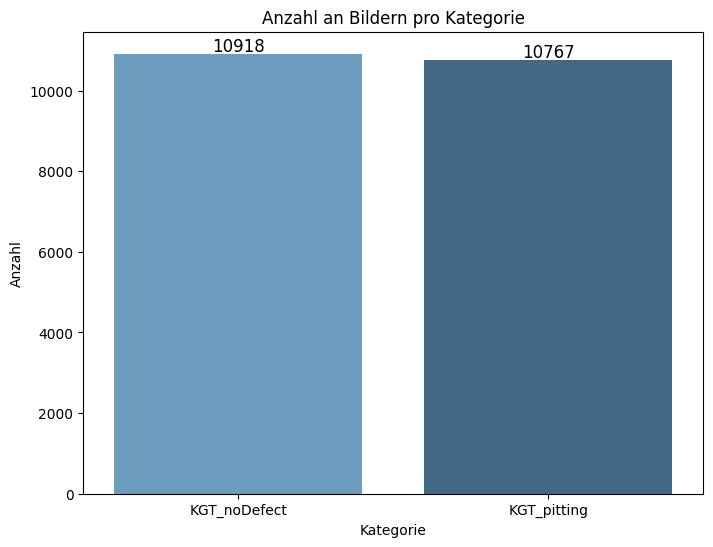

21685


In [3]:
df = pd.DataFrame({
    'Folder': ['KGT_noDefect', 'KGT_pitting'],
    'File Count': [len(no_defect), len(pitting)]
})

plt.figure(figsize=(8, 6))
barplot = sns.barplot(x='Folder', y='File Count', hue="Folder",data=df, palette='Blues_d', legend=False)

plt.title('Anzahl an Bildern pro Kategorie')
plt.xlabel('Kategorie')
plt.ylabel('Anzahl')

for p in barplot.patches:
    barplot.annotate(f'{int(p.get_height())}', 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='center', 
                      fontsize=12, color='black', 
                      xytext=(0, 5), textcoords='offset points')

plt.show()

sum = len(no_defect) + len(pitting)
print(sum)

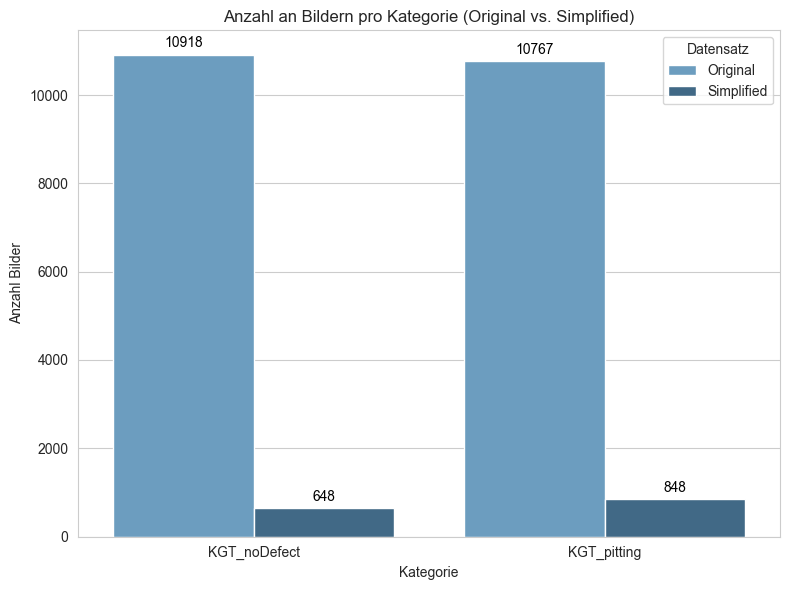

Original: 21685, Simplified: 1496


In [4]:
# Werte vorbereiten
df = pd.DataFrame({
    'Kategorie': ['KGT_noDefect', 'KGT_noDefect', 'KGT_pitting', 'KGT_pitting'],
    'Datensatz': ['Original', 'Simplified', 'Original', 'Simplified'],
    'Anzahl': [len(no_defect), 648, len(pitting), 848]
})

# Plot
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
barplot = sns.barplot(
    x='Kategorie', y='Anzahl', hue='Datensatz',
    data=df, palette='Blues_d'
)

# Beschriftung
plt.title('Anzahl an Bildern pro Kategorie (Original vs. Simplified)')
plt.xlabel('Kategorie')
plt.ylabel('Anzahl Bilder')

for p in barplot.patches:
    height = int(p.get_height())
    if height != 0: 
        barplot.annotate(f'{height}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom',
                        fontsize=10, color='black',
                        xytext=(0, 3), textcoords='offset points')

plt.legend(title='Datensatz')
plt.tight_layout()
plt.show()

# Optional: Summen
original_total = len(no_defect) + len(pitting)
simplified_total = 648 + 848
print(f"Original: {original_total}, Simplified: {simplified_total}")

In [5]:
for patch in barplot.patches: 
    print(patch.get_height())
    print((patch.get_x() + patch.get_width() / 2., height))

10918.0
(np.float64(-0.2), 0)
10767.0
(np.float64(0.8), 0)
648.0
(np.float64(0.20000000000000007), 0)
848.0
(np.float64(1.2000000000000002), 0)
0
(0.0, 0)
0
(0.0, 0)


In [6]:
img_path = os.path.join(data_path, "KGT_noDefect", no_defect[0])

img = Image.open(img_path)

img.mode

'RGB'

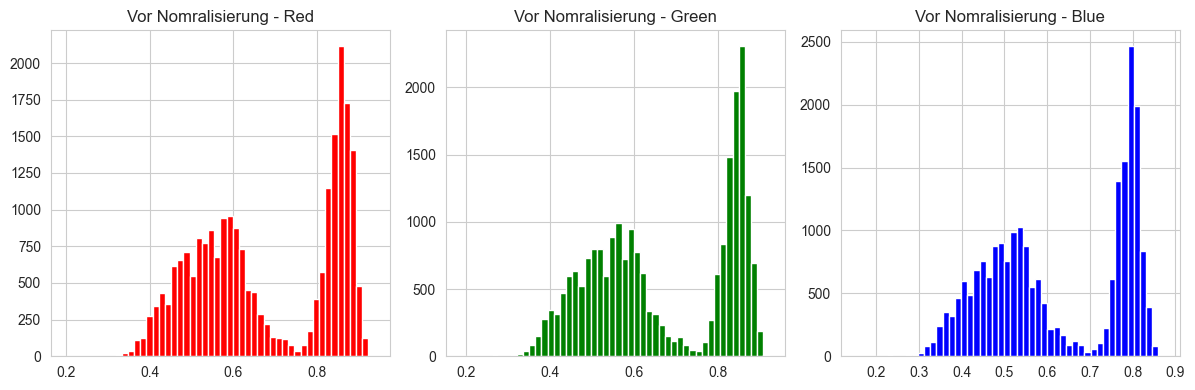

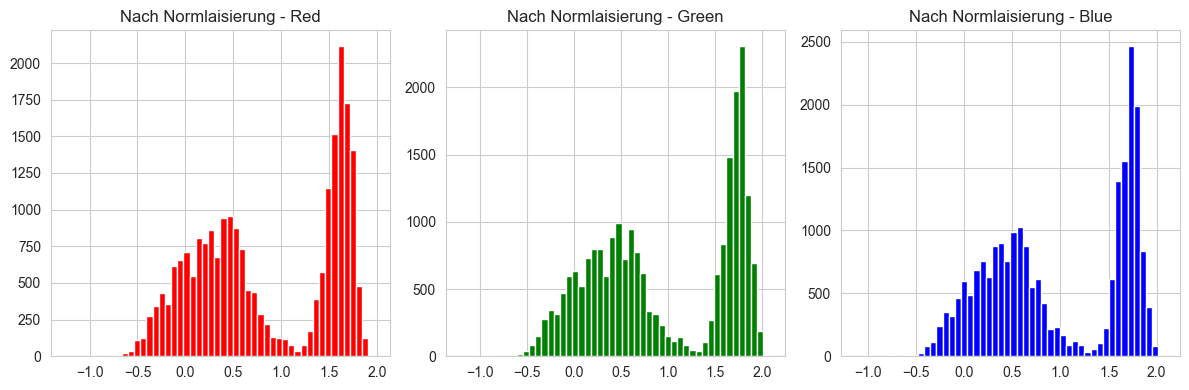

In [7]:
# Define transforms
to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], #values used in pretraining 
    std=[0.229, 0.224, 0.225]
)

# Apply transformations
tensor_img = to_tensor(img)
normalized_img = normalize(tensor_img)

# Plot histograms
def plot_histogram(tensor, title):
    plt.figure(figsize=(12, 4))
    channels = ['Red', 'Green', 'Blue']
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.hist(tensor[i].flatten().numpy(), bins=50, color=channels[i].lower())
        plt.title(f'{title} - {channels[i]}')
    plt.tight_layout()
    plt.show()

plot_histogram(tensor_img, "Vor Nomralisierung")
plot_histogram(normalized_img, "Nach Normlaisierung")

<h1> Model Training <h1>

In diesem Abschnitt implementieren wir ein vortrainiertes Convolutional Neural Network (CNN) und passen es an unseren Datensatz an (Finetuning). Dabei verwenden wir ResNet-18 von Microsoft, ein bewährtes Modell, das in unserem Bericht ausführlicher beschrieben wird.
Zur Untersuchung des Einflusses von Datenaugmentation werden die Eingabebilder in drei Varianten verarbeitet: zunächst mit minimalen Transformationen, anschließend mit moderater und schließlich mit starker Augmentierung. Die Ergebnisse dieser drei Varianten vergleichen wir anschließend hinsichtlich ihrer Modell-Performance.

### Transformationspipeline für Trainingsdaten

Diese Bildtransformationen werden verwendet, um das Modell robuster und generalisierungsfähiger zu machen:

- **Resize(256)**: Skaliert die kürzeste Seite des Bildes auf 256 Pixel, um eine einheitliche Ausgangsgröße zu schaffen.
- **RandomResizedCrop(224)**: Schneidet zufällig einen Bereich aus dem Bild aus und skaliert ihn auf 224×224 Pixel. Dies simuliert verschiedene Zoom- und Zuschnittsituationen. Die Größe von 224x224 Pixel wurde gewählt, da ResNet, so wie viele andere (vortrainierte) CNN diese Inputgröße erwarten
- **RandomHorizontalFlip()**: Spiegelt das Bild zufällig horizontal (mit 50 % Wahrscheinlichkeit), um Symmetrie zu nutzen.
- **ColorJitter**:
  - `brightness=0.2`: Zufällige Helligkeit (±20 %)
  - `contrast=0.2`: Zufälliger Kontrast (±20 %)
  - `saturation=0.2`: Zufällige Farbsättigung (±20 %)
  - `hue=0.05`: Zufälliger Farbton (±5 %)
 
  Diese Veränderung der Farben erhöht die Vielfalt künstlich.
- **RandomRotation(10)**: Rotiert das Bild zufällig im Bereich von ±10°, um leichte Schräglagen zu simulieren.
- **ToTensor()**: Konvertiert das PIL-Bild in einen PyTorch-Tensor im Format **CHW** (`[Channels, Height, Width]`) und skaliert die Werte in den Bereich [0.0, 1.0].
- **Normalize(mean, std)**: Wendet eine Normalisierung mit den **ImageNet-Statistiken** an (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`), damit das Modell die gleichen Datenverteilungen wie beim Pretraining sieht.

> Ziel: Diese Pipeline hilft dem Modell, sich nicht auf bestimmte Bildpositionen, -farben oder -ausrichtungen zu verlassen und dadurch robuster zu werden. Wir werden im folgenden drei verschiedenen Transformationen definieren, die eine (Teil-)Menge der Beschriebenen Funktionenn enthalten 


<h2> Festlgung der Transformationen </h2>

Für die Trainings-/Validierungs-Daten wurde eine andere Transformation gewählt als für die Test-Daten. Der Grund hierfür ist, dass das Laden der Daten aus dem jeweiligen Datensatz lazy passiert. Die Daten werden nicht vor dem Laden in den definierten Test-Datenstz transformiert, sondern erst wenn sie tatsächlich gebracht werden. Damit ist das Laden von Bilddaten (Tensoren) aufgrund der stochastischen Operationen (RandomReistedCrop, RandomHorizontalFlip etc.) nicht deterministisch, wodurch die Performance-Metrics bei mehrfachem Testen leicht unterschiedlch wären. Deshalb definieren wir für den Testdatensatz deterministische Transformatoren, um Replizierbarkeit zu gewährleisten.

Würde man auch bei den Test Bildern stochastische Transformationen anwenden, wären die Ergebnisse zwar robuster, aber nicht (so gut) reproduzierbar

In [8]:
# Training & Validierung 

# Light
train_transform_light = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Medium
train_transform_medium = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Strong
train_transform_strong = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
    ),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Test 

# Light
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

"""
# Medium
test_transform_medium = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ColorJitter(
        brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Strong
test_transform_strong = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
"""

'\n# Medium\ntest_transform_medium = transforms.Compose([\n    transforms.Resize(256),\n    transforms.CenterCrop(224),\n    transforms.ColorJitter(\n        brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02\n    ),\n    transforms.ToTensor(),\n    transforms.Normalize(\n        mean=[0.485, 0.456, 0.406],\n        std=[0.229, 0.224, 0.225]\n    )\n])\n\n# Strong\ntest_transform_strong = transforms.Compose([\n    transforms.Resize(256),\n    transforms.CenterCrop(224),\n    transforms.ColorJitter(\n        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05\n    ),\n    transforms.ToTensor(),\n    transforms.Normalize(\n        mean=[0.485, 0.456, 0.406],\n        std=[0.229, 0.224, 0.225]\n    )\n])\n'

In [9]:
# Datensätze separat laden

def load_full_datasets(transformation: str): 
    transform = {
        "light" : [train_transform_light, test_transform], 
        "medium" : [train_transform_medium, test_transform], 
        "strong" : [train_transform_strong, test_transform]
    }
    full_dataset_train_val = datasets.ImageFolder(
        root=os.path.join(BASE, "dataset"), transform=transform[transformation][0])

    full_dataset_test = datasets.ImageFolder(
        root=os.path.join(BASE, "dataset"), transform=transform[transformation][1])
    
    return full_dataset_train_val, full_dataset_test


In [10]:
full_dataset_train_val_light, full_dataset_test_light = load_full_datasets("light")
full_dataset_train_val_medium, full_dataset_test_medium = load_full_datasets("medium")
full_dataset_train_val_strong, full_dataset_test_strong = load_full_datasets("strong")

In [11]:
def make_split(train_val, test): 

    # Aufteilen
    total_size = len(train_val)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size

    # Split-Indices
    generator = torch.Generator().manual_seed(42)
    train_val_indices = torch.randperm(total_size, generator=generator)

    # Subsets (verwende die gleichen Indices!)
    train_indices = train_val_indices[:train_size]
    val_indices = train_val_indices[train_size:train_size + val_size]
    test_indices = train_val_indices[train_size + val_size:]

    # Trainings- & Validierungssets mit augmentierten Daten
    train_dataset = torch.utils.data.Subset(train_val, train_indices)
    val_dataset = torch.utils.data.Subset(train_val, val_indices)

    # Testset mit deterministischen Daten
    test_dataset = torch.utils.data.Subset(test, test_indices)

    return train_dataset, val_dataset, test_dataset

In [12]:
train_set_light, val_set_light, test_set_light = make_split(full_dataset_train_val_light, full_dataset_test_light)
train_set_medium, val_set_medium, test_set_medium = make_split(full_dataset_train_val_medium, full_dataset_test_medium)
train_set_strong, val_set_strong, test_set_strong = make_split(full_dataset_train_val_strong, full_dataset_test_strong)

In [13]:
def make_loader(train_set, val_set, test_set): 
    train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

    return train_loader, val_loader, test_loader

In [14]:
train_loader_light, val_loader_light, test_loader_light = make_loader(train_set_light, val_set_light, test_set_light)
train_loader_medium, val_loader_medium, test_loader_medium = make_loader(train_set_medium, val_set_medium, test_set_medium)
train_loader_strong, val_loader_strong, test_loader_strong = make_loader(train_set_strong, val_set_strong, test_set_strong)

In [17]:
# Execute this cell before training or loading model

model = models.resnet18(pretrained=True)

# Modify the final layer for binary classification
model.fc = nn.Linear(model.fc.in_features, 2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
def save_model(model, transformation): 
    torch.save(model.state_dict(), os.path.join(BASE, "models",  f"resnet18_pitting_not_simplified_{transformation}.pth"))

def save_metrics(train_losses: list, val_losses: list, train_time, transformation: str): 
    losses = {
        "train_loss": train_losses, 
        "val_loss": val_losses,
        "train_time": train_time
    }

    # path 
    save_path = os.path.join(BASE, "models", f"metrics_{transformation}.pkl")

    # save
    with open(save_path, "wb") as f:
        pickle.dump(losses, f)

def load_metrics(transformation: str = None): 
    filename = f"metrics_{transformation}.pkl" if transformation else "metrics.pkl"
    load_path = os.path.join(BASE, "models", filename)

    # Laden
    with open(load_path, "rb") as f:
        metrics = pickle.load(f)
    
    return metrics

def train_model(train_loader, val_loader, transformation: str, device): 

    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Training loop with validation
    num_epochs = 10
    train_losses = []
    val_losses = []

    t1 = time() 

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        train_losses.append(running_train_loss)

        # Validation loop
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

        val_losses.append(running_val_loss)

        print(f"Epoch {epoch+1} | Train Loss: {running_train_loss:.4f} | Val Loss: {running_val_loss:.4f}")
    
    t2 = time() 

    train_time = t2 - t1

    save_model(model, transformation)
    save_metrics(train_losses, val_losses, train_time, transformation)

    return model

In [16]:
model_params = {
    "light": [train_loader_light, val_loader_light], 
    "medium": [train_loader_medium, val_loader_medium], 
    "strong": [train_loader_strong, val_loader_strong]
}

trained_models = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for transformation in model_params.keys(): 
    train_loader = model_params[transformation][0]
    val_loader = model_params[transformation][1]
    trained_model = train_model(train_loader, val_loader, transformation, device)
    trained_models.append(trained_model)
    

/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 65.8162 | Val Loss: 4.2210
Epoch 2 | Train Loss: 19.2909 | Val Loss: 9.8917
Epoch 3 | Train Loss: 14.8066 | Val Loss: 6.2564
Epoch 4 | Train Loss: 16.3114 | Val Loss: 3.7188
Epoch 5 | Train Loss: 7.9055 | Val Loss: 3.7293
Epoch 6 | Train Loss: 11.8543 | Val Loss: 1.3997
Epoch 7 | Train Loss: 11.5381 | Val Loss: 4.2269
Epoch 8 | Train Loss: 9.1511 | Val Loss: 1.1759
Epoch 9 | Train Loss: 4.6333 | Val Loss: 3.0638
Epoch 10 | Train Loss: 11.6432 | Val Loss: 2.1751
Epoch 1 | Train Loss: 79.3747 | Val Loss: 7.5025
Epoch 2 | Train Loss: 31.0279 | Val Loss: 3.9508
Epoch 3 | Train Loss: 28.0799 | Val Loss: 9.1757
Epoch 4 | Train Loss: 23.8793 | Val Loss: 4.3266
Epoch 5 | Train Loss: 24.5080 | Val Loss: 2.2467
Epoch 6 | Train Loss: 14.5182 | Val Loss: 4.7690
Epoch 7 | Train Loss: 17.8210 | Val Loss: 3.4791
Epoch 8 | Train Loss: 13.6317 | Val Loss: 2.4976
Epoch 9 | Train Loss: 13.7936 | Val Loss: 2.0039
Epoch 10 | Train Loss: 13.0202 | Val Loss: 2.1134
Epoch 1 | Train Loss:

In [17]:
def plot_losses(losses, transformation):
    epochs = list(range(1, len(losses["train_loss"]) + 1))
    
    df = pd.DataFrame({
        "Epoche": epochs * 2,
        "Loss": losses["train_loss"] + losses["val_loss"],
        "Typ": ["Training"] * len(epochs) + ["Validierung"] * len(epochs)
    })
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="Epoche", y="Loss", hue="Typ", style="Typ", markers=True, dashes=False)

    plt.title(f"Verlust (Loss) pro Epoche | Transformation: {transformation}", fontsize=14)
    plt.xlabel("Epoche", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(title="Datentyp", loc="upper right")
    plt.tight_layout()
    plt.show()

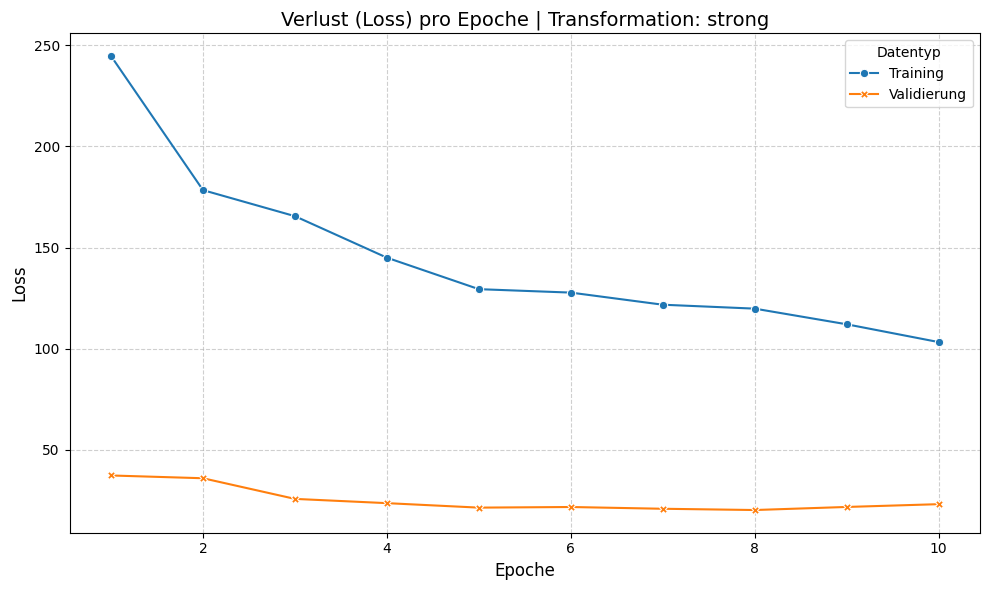

In [18]:
losses = load_losses()
testfig = plot_losses(losses, "strong")

In [65]:
#load model
def load_model(transformation: str = None): 
    model = models.resnet18(pretrained=False)
    model.fc = torch.nn.Linear(model.fc.in_features, 2)  # 2 classes
    filename = f"resnet18_pitting_not_simplified_{transformation}.pth" if transformation else "resnet18_pitting_not_simplified.pth"
    load_path = os.path.join(BASE, "models", filename)
    model.load_state_dict(torch.load(load_path))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device) 
    return model 


In [19]:
model = load_model()

/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<h1> Testing </h1> 

In [66]:
light_model = load_model("light")
medium_model = load_model("medium")
strong_model = load_model("strong")


/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [165]:
time_light = load_metrics("light")["train_time"] /60
time_medium = load_metrics("medium")["train_time"] /60
time_strong = load_metrics("strong")["train_time"] /60

print(time_light, time_medium, time_strong)

216.00509713490803 194.76295837163926 373.17380118370056


In [ ]:
def test_model(model, test_loader, class_names=None, return_metrics=False):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # metrics
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, digits=4)

    print(f"Test Accuracy: {acc:.4f}")
    print("\n Classification Report:")
    print(report)

    # Confusion matrix 
    plt.figure(figsize=(8, 6))
    try: 
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
    except: 
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Vorhergesagte Klasse")
    plt.ylabel("Wahre Klasse")
    plt.title("Konfusionsmatrix")
    plt.tight_layout()
    plt.show()

    if return_metrics:
        return acc, cm, report

Test Accuracy: 0.9960

 Classification Report:
              precision    recall  f1-score   support

           0     0.9952    0.9970    0.9961      1672
           1     0.9968    0.9949    0.9959      1582

    accuracy                         0.9960      3254
   macro avg     0.9960    0.9960    0.9960      3254
weighted avg     0.9960    0.9960    0.9960      3254



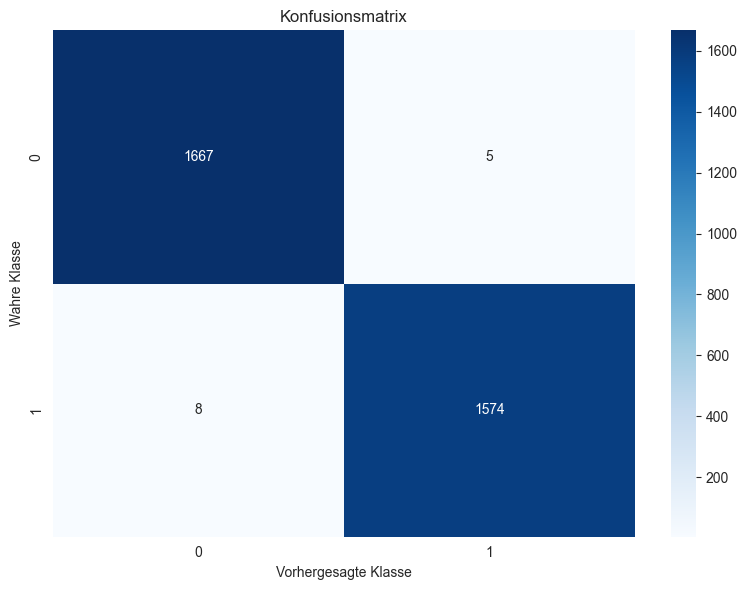

In [69]:
test_model(light_model, test_loader_light)

Test Accuracy: 0.9978

 Classification Report:
              precision    recall  f1-score   support

           0     0.9988    0.9970    0.9979      1672
           1     0.9968    0.9987    0.9978      1582

    accuracy                         0.9978      3254
   macro avg     0.9978    0.9979    0.9978      3254
weighted avg     0.9979    0.9978    0.9978      3254



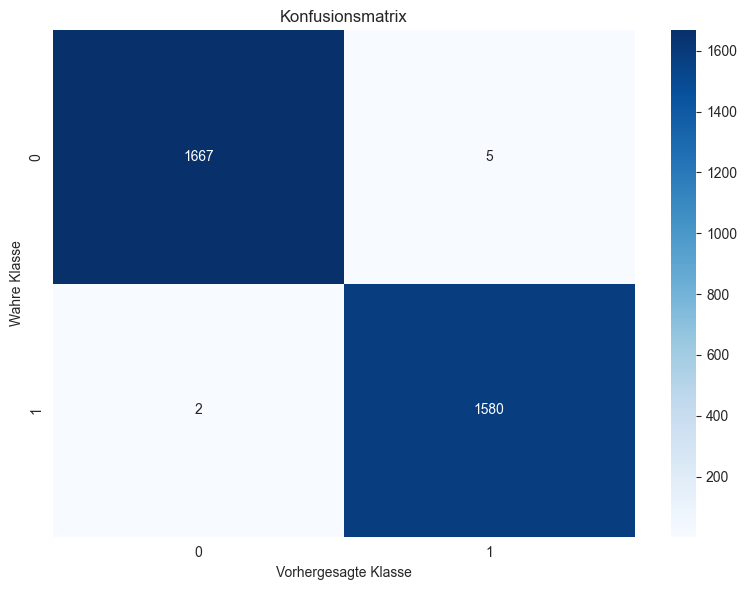

In [70]:
test_model(medium_model, test_loader_medium)

Test Accuracy: 0.9963

 Classification Report:
              precision    recall  f1-score   support

           0     0.9970    0.9958    0.9964      1672
           1     0.9956    0.9968    0.9962      1582

    accuracy                         0.9963      3254
   macro avg     0.9963    0.9963    0.9963      3254
weighted avg     0.9963    0.9963    0.9963      3254



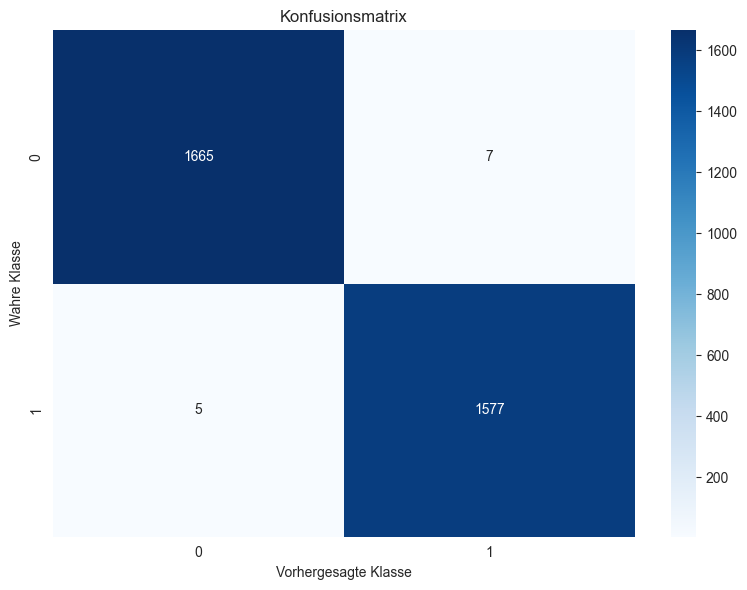

In [71]:
test_model(strong_model, test_loader_strong)

Test Accuracy: 0.9951

 Classification Report:
              precision    recall  f1-score   support

           0     0.9970    0.9934    0.9952      1672
           1     0.9931    0.9968    0.9950      1582

    accuracy                         0.9951      3254
   macro avg     0.9950    0.9951    0.9951      3254
weighted avg     0.9951    0.9951    0.9951      3254



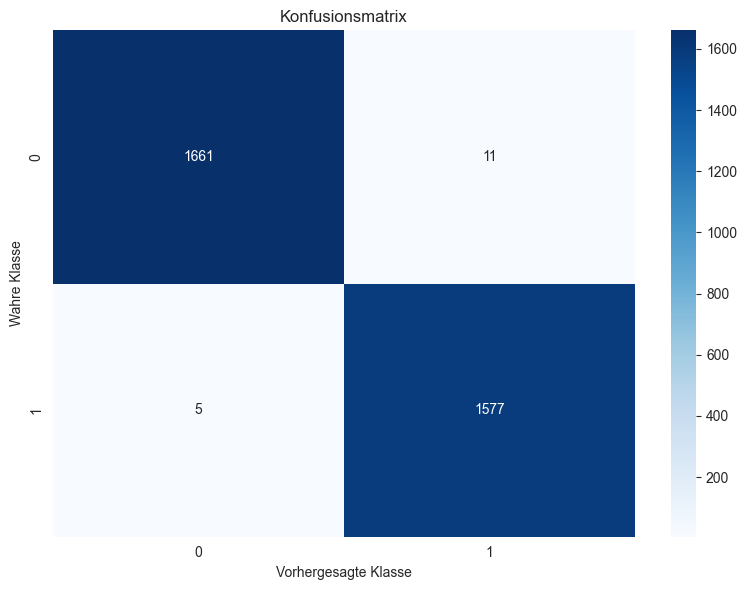

In [21]:
test_model(model, test_loader_strong)

<h1> Visualisierung </h1>

<h2> Transfomration </h2>

In [ ]:
# Beispielpfad zu einem Bild im Datensatz (original, unbearbeitet)
image_path = os.path.join(BASE, "data", "KGT_pitting", "P (9).png")
original_image = Image.open(image_path).convert("RGB")

In [133]:
image = r"/Users/janikwahrheit/Downloads/Oel_pit_h.jpg"
image = Image.open(image).convert("RGB")
image_tensor = test_transform(image)
#image_tensor = image_tensor.unsqueeze(0)

image_tensor.size()


torch.Size([3, 224, 224])

In [97]:
# Bild transformieren
light_tensor = train_transform_light(original_image)
medium_tensor =  train_transform_medium(original_image)
strong_tensor = train_transform_strong(original_image)

In [100]:
def transform_img(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).reshape(-1, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).reshape(-1, 1, 1)
    unnormalized_tensor = tensor * std + mean
    transformed_image = unnormalized_tensor.permute(1, 2, 0).numpy().clip(0, 1)
    return transformed_image

img_light = transform_img(light_tensor)
img_medium = transform_img(medium_tensor)
img_strong = transform_img(strong_tensor)

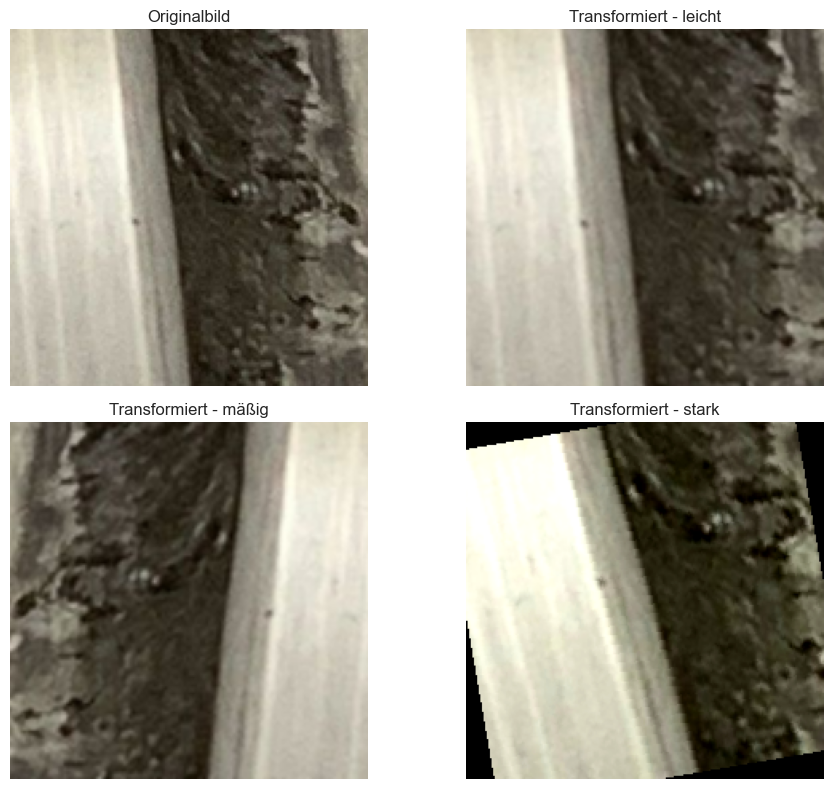

In [103]:
# Bild transformieren
light_tensor = train_transform_light(original_image)
medium_tensor =  train_transform_medium(original_image)
strong_tensor = train_transform_strong(original_image)


img_light = transform_img(light_tensor)
img_medium = transform_img(medium_tensor)
img_strong = transform_img(strong_tensor)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Originalbild")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_light)
axes[0, 1].set_title("Transformiert - leicht")
axes[0, 1].axis("off")

axes[1, 0].imshow(img_medium)
axes[1, 0].set_title("Transformiert - mäßig")
axes[1, 0].axis("off")

axes[1, 1].imshow(img_strong)
axes[1, 1].set_title("Transformiert - stark")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


<h2> Inferenz </h2>

In [105]:
for i in range(100): 
    image_tensor, label = test_set_strong[i] 
    if label == 1: 
        print(i)
        break 

0


In [170]:
image_tensor, label = test_set_strong[32] 
label

1

In [169]:
image_tensor2 = image_tensor

In [171]:

image_tensor_batched = image_tensor.unsqueeze(0)
image_tensor_batched
image_tensor.size()



torch.Size([3, 224, 224])

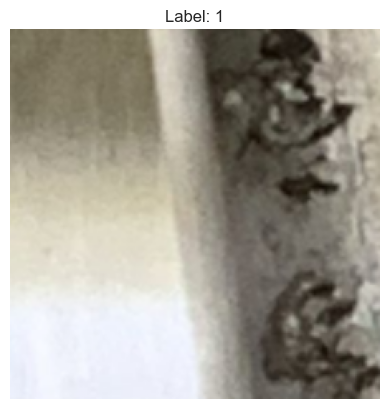

In [172]:
# Unnormalize the image (reverse the normalization applied in the transform)
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
unnormalized_image = image_tensor * std[:, None, None] + mean[:, None, None]


image_np = unnormalized_image.permute(1, 2, 0).numpy()

# Display the image
plt.imshow(image_np)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


In [177]:
def plot_heatmap(model, img_tensor):

    gradients = []
    
    if img_tensor.shape != (1, 3, 224, 224):
        if img_tensor.shape == (3, 224, 224):
                image_tensor_batched = img_tensor.unsqueeze(0)
        else:
            raise ValueError(f"Unerwartete Bildgröße: {img_tensor.shape}")
    else:
        image_tensor_batched = img_tensor

    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    unnormalized_image = img_tensor * std[:, None, None] + mean[:, None, None]

    image_np = unnormalized_image.permute(1, 2, 0).numpy()


    def save_gradient(grad):
        gradients.append(grad)

    #Forward hook for activations
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)
        output.register_hook(save_gradient)

    # Register the hook to the last conv layer of ResNet18
    target_layer = model.layer4
    hook = target_layer.register_forward_hook(forward_hook)

    # Forward pass
    output = model(image_tensor_batched)
    pred_class = output.argmax(dim=1).item()

    #Backward pass for Grad-CAM 
    model.zero_grad()
    output[0, pred_class].backward()

    # Get activations and gradients 
    grads_val = gradients[0][0].cpu().detach().numpy()  # (C, H, W)
    acts_val = activations[0][0].cpu().detach().numpy()  # (C, H, W)

    # Compute the weights and CAM
    weights = np.mean(grads_val, axis=(1, 2))  # Global average pooling
    cam = np.zeros(acts_val.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts_val[i, :, :]

    #Normalize and resize the CAM 
    cam = np.maximum(cam, 0)  # ReLU
    cam = cam - cam.min()
    cam = cam / cam.max()
    cam = cv2.resize(cam, (224, 224))

    # Overlay the heatmap on the image 
    #img_np = np.array(image.resize((224, 224)))  # Original image
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    inverted_heatmap = cv2.bitwise_not(heatmap)
    image_uint8 = (image_np * 255).astype(np.uint8)
    overlay = heatmap * 0.4 + image_uint8 * 0.6
    overlay = np.uint8(overlay)

    # Show the result 
    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.title(f"Predicted: {pred_class} ({'Pitting' if pred_class == 1 else 'No Defect'})")
    plt.axis('off')
    plt.show()

    # Cleanup
    hook.remove()

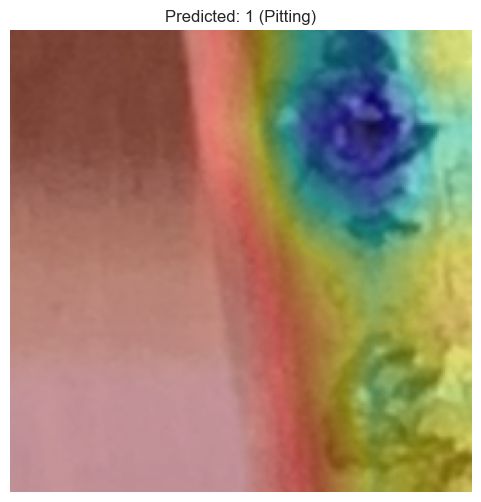

In [178]:
plot_heatmap(medium_model, image_tensor)

In [63]:
dfs = []
for name in ["light", "medium", "strong"]:
    metric = load_metrics(name)
    epochs = list(range(1, 10 + 1))
    df = pd.DataFrame({
        "epoch": epochs,
        "train_loss": metric["train_loss"],
        "val_loss": metric["val_loss"],
        "transformation": [name] * len(metric["train_loss"])
    })
    dfs.append(df)


losses = pd.concat(dfs, ignore_index=True)



In [52]:
df_melted = losses.melt(id_vars=['epoch', 'transformation'], 
                    value_vars=['train_loss', 'val_loss'],
                    var_name='Loss Type', 
                    value_name='Loss')

df_melted

,epoch,transformation,Loss Type,Loss
0,1,light,train_loss,65.816246
1,2,light,train_loss,19.290882
2,3,light,train_loss,14.806589
3,4,light,train_loss,16.311431
4,5,light,train_loss,7.905484
5,6,light,train_loss,11.854332
6,7,light,train_loss,11.538133
7,8,light,train_loss,9.151077
8,9,light,train_loss,4.633289
9,10,light,train_loss,11.643239


/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_11783/1445455251.py:2: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data=df_melted, x='epoch', y='Loss',


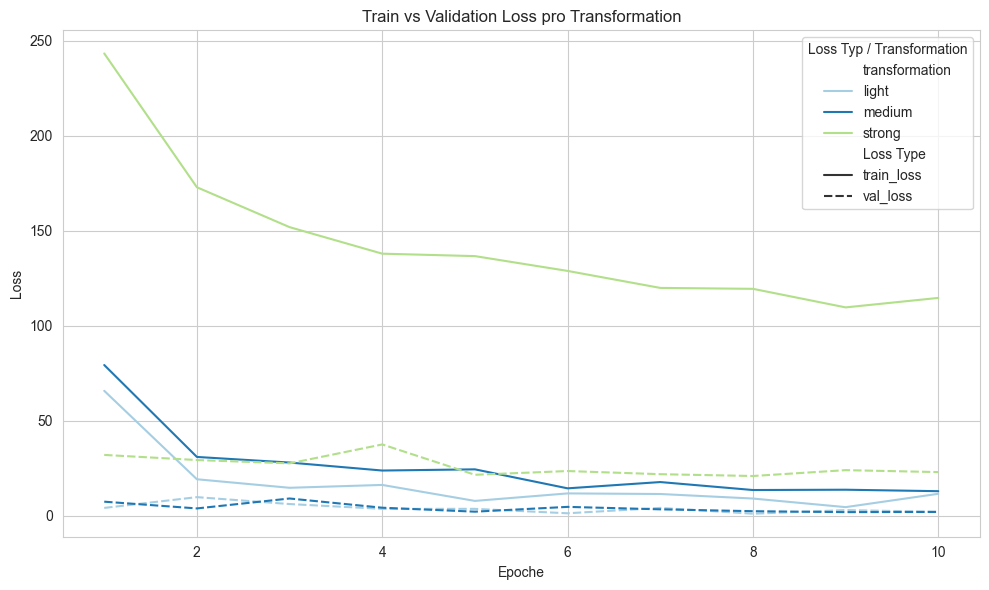

In [61]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='epoch', y='Loss',
             hue='transformation', style='Loss Type', markers=False, dashes=True, palette=sns.color_palette("Paired"))

plt.title('Train vs Validation Loss pro Transformation')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend(title='Loss Typ / Transformation')
plt.tight_layout()
plt.show()